<a href="https://colab.research.google.com/github/mjsonu/ParkinsonsCNN/blob/main/Parkinsons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install kagglehub
!pip install -q kagglehub

# Download dataset
import kagglehub

path = kagglehub.dataset_download("irfansheriff/parkinsons-brain-mri-dataset")

print("Path to dataset files:", path)

100%|██████████| 25.8M/25.8M [00:00<00:00, 84.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/irfansheriff/parkinsons-brain-mri-dataset/versions/1


In [5]:
import os

for root, dirs, files in os.walk(path):
    print("Root:", root)
    print("Folders:", dirs)
    print("Files:", len(files))
    print("-" * 40)

Root: /root/.cache/kagglehub/datasets/irfansheriff/parkinsons-brain-mri-dataset/versions/1
Folders: ['parkinsons_dataset']
Files: 0
----------------------------------------
Root: /root/.cache/kagglehub/datasets/irfansheriff/parkinsons-brain-mri-dataset/versions/1/parkinsons_dataset
Folders: ['normal', 'parkinson']
Files: 0
----------------------------------------
Root: /root/.cache/kagglehub/datasets/irfansheriff/parkinsons-brain-mri-dataset/versions/1/parkinsons_dataset/normal
Folders: []
Files: 610
----------------------------------------
Root: /root/.cache/kagglehub/datasets/irfansheriff/parkinsons-brain-mri-dataset/versions/1/parkinsons_dataset/parkinson
Folders: []
Files: 221
----------------------------------------


In [7]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Path to dataset
data_dir = path + "/parkinsons_dataset"

IMG_SIZE = 224
BATCH_SIZE = 32

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transforms)

# Train-validation split (80-20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


val_dataset.dataset.transform = val_transforms


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


print("Class to index:", full_dataset.class_to_idx)
print("Train size:", train_size)
print("Validation size:", val_size)

Class to index: {'normal': 0, 'parkinson': 1}
Train size: 664
Validation size: 167


In [10]:
import os

# Corrected paths using the 'path' variable from dataset download
normal_path = os.path.join(path, "parkinsons_dataset", "normal")
parkinson_path = os.path.join(path, "parkinsons_dataset", "parkinson")

normal_count = len(os.listdir(normal_path))
parkinson_count = len(os.listdir(parkinson_path))

print(f"Normal: {normal_count}")
print(f"Parkinson: {parkinson_count}")

Normal: 610
Parkinson: 221


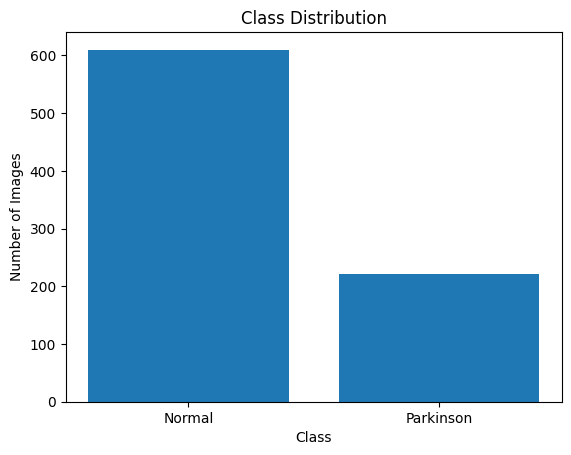

In [11]:
import matplotlib.pyplot as plt

labels = ['Normal', 'Parkinson']
counts = [normal_count, parkinson_count]

plt.bar(labels, counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

**Random Images from both Dataset**

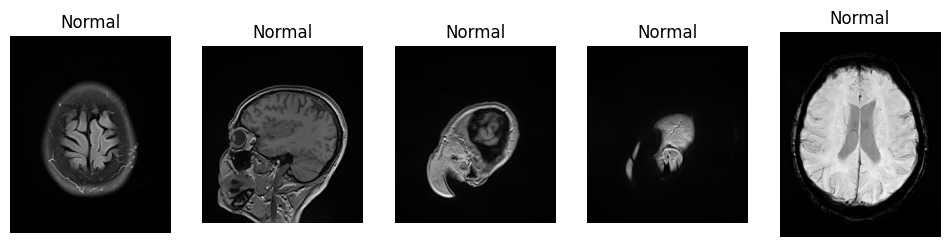

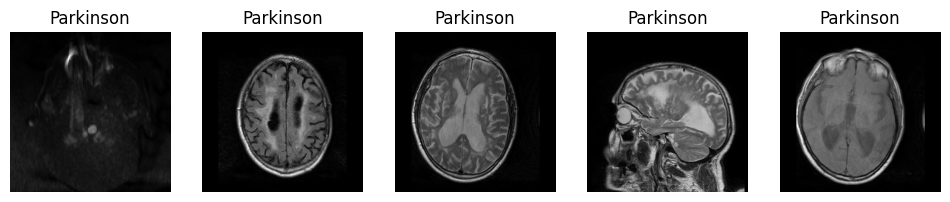

In [12]:
import random
from PIL import Image

def show_samples(folder, title):
    images = os.listdir(folder)
    sample_images = random.sample(images, 5)

    plt.figure(figsize=(12, 3))
    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path)

        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')

    plt.show()

show_samples(normal_path, "Normal")
show_samples(parkinson_path, "Parkinson")

In [13]:
sizes = []

for folder in [normal_path, parkinson_path]:
    for img_name in os.listdir(folder)[:50]:  # sample 50 images
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)

print("Sample image sizes:", sizes[:10])

Sample image sizes: [(192, 192), (250, 320), (250, 320), (250, 320), (250, 320), (232, 256), (232, 256), (250, 320), (250, 320), (250, 320)]


In [14]:
from PIL import Image
import os

sample_img = Image.open(os.path.join(normal_path, os.listdir(normal_path)[0]))
print("Image mode:", sample_img.mode)

Image mode: L


In [15]:
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # 🔥 IMPORTANT
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet stats
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # 🔥 IMPORTANT
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [16]:
import torch
import torch.nn as nn
from torchvision import models

# Device (T4 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load EfficientNet
model = models.efficientnet_b0(pretrained=True)

# Remove classifier (keep feature extractor)
model.classifier = nn.Identity()

model = model.to(device)
model.eval()  # important for feature extraction

print(model)

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 105MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [17]:
# Get one batch
images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    features = model(images)

print("Feature shape:", features.shape)

Feature shape: torch.Size([32, 1280])


In [18]:
import numpy as np

def extract_features(dataloader, model, device):
    features_list = []
    labels_list = []

    model.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)  # (batch_size, 1280)

            features_list.append(outputs.cpu().numpy())
            labels_list.append(labels.numpy())

    features = np.vstack(features_list)
    labels = np.hstack(labels_list)

    return features, labels

In [19]:
train_features, train_labels = extract_features(train_loader, model, device)
val_features, val_labels = extract_features(val_loader, model, device)

print("Train features shape:", train_features.shape)
print("Train labels shape:", train_labels.shape)

print("Val features shape:", val_features.shape)
print("Val labels shape:", val_labels.shape)

Train features shape: (664, 1280)
Train labels shape: (664,)
Val features shape: (167, 1280)
Val labels shape: (167,)


In [20]:
np.save("train_features.npy", train_features)
np.save("train_labels.npy", train_labels)

np.save("val_features.npy", val_features)
np.save("val_labels.npy", val_labels)

**Featture reduction** (PCA)

In [21]:
from sklearn.decomposition import PCA

# Choose number of components
n_components = 200  # you can tune later

pca = PCA(n_components=n_components)

# Fit ONLY on train data
train_features_pca = pca.fit_transform(train_features)

# Transform validation data
val_features_pca = pca.transform(val_features)

print("Train PCA shape:", train_features_pca.shape)
print("Val PCA shape:", val_features_pca.shape)

Train PCA shape: (664, 200)
Val PCA shape: (167, 200)


In [22]:
print("Total explained variance:", sum(pca.explained_variance_ratio_))

Total explained variance: 0.97567755


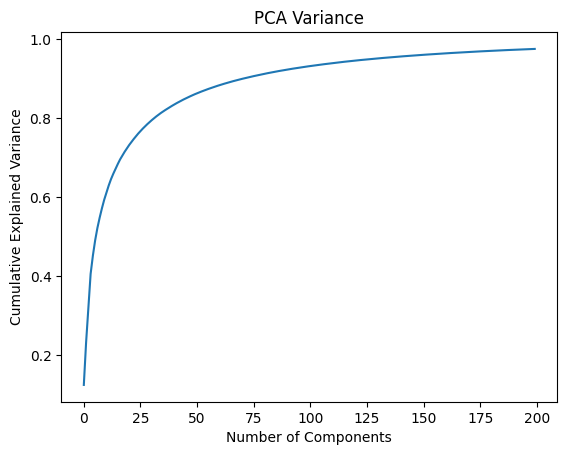

In [23]:
import matplotlib.pyplot as plt

plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance")
plt.show()

### Keep Runtime Alive

The following cell will run a counter indefinitely to keep the Colab runtime from disconnecting due to inactivity. You can manually stop this cell when you are done.

**Voting Model**

In [24]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [25]:
# SVM (very strong for this setup)
svm_model = SVC(probability=True, kernel='rbf', C=10, gamma='scale')

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# XGBoost (powerful)
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss'
)

Voting (soft)



In [26]:
voting_model = VotingClassifier(
    estimators=[
        ('svm', svm_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)

In [27]:
voting_model.fit(train_features_pca, train_labels)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:53:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


VotingClassifier(estimators=[('svm', SVC(C=10, probability=True)),
                             ('rf',
                              RandomForestClassifier(max_depth=10,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [28]:
# Predictions
y_pred = voting_model.predict(val_features_pca)
y_proba = voting_model.predict_proba(val_features_pca)[:, 1]

# Metrics
accuracy = accuracy_score(val_labels, y_pred)
f1 = f1_score(val_labels, y_pred)
roc_auc = roc_auc_score(val_labels, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.9820
F1 Score: 0.9655
ROC-AUC: 0.9998


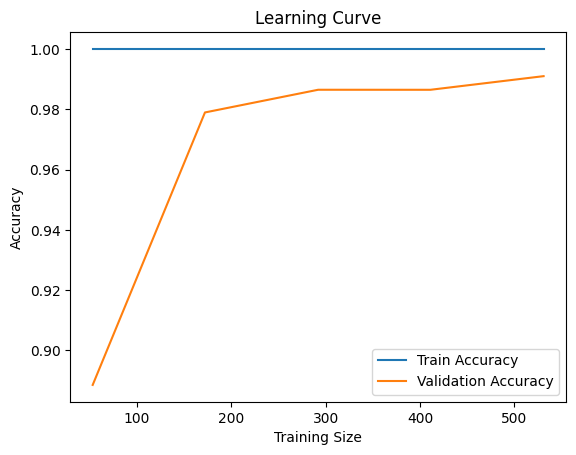

In [29]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    voting_model,
    train_features_pca,
    train_labels,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Train Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

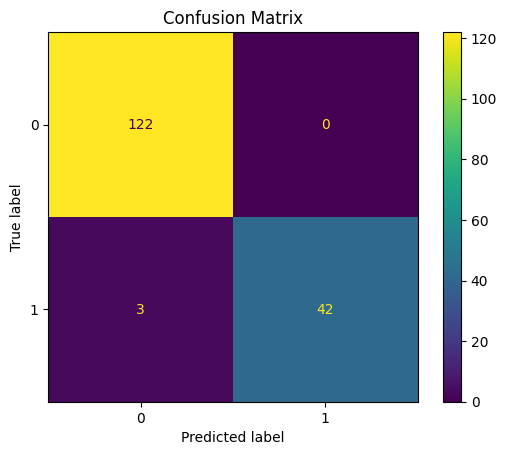

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(val_labels, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [31]:
import joblib

In [32]:
joblib.dump({
    "pca": pca,
    "model": voting_model
}, "parkinsons_pipeline.pkl")

['parkinsons_pipeline.pkl']

**Seeing predictions**

In [38]:
import math
import matplotlib.pyplot as plt
import numpy as np

class_names = ['Normal', 'Parkinson']

def show_predictions(model, cnn_model, pca, dataloader, device, num_images=20):
    cnn_model.eval()

    cols = 5
    rows = math.ceil(num_images / cols)

    plt.figure(figsize=(15, 3 * rows))

    images_shown = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            # CNN → features
            features = cnn_model(images).cpu().numpy()

            # PCA
            features_pca = pca.transform(features)

            # Predictions
            preds = model.predict(features_pca)
            probs = model.predict_proba(features_pca)

            for i in range(len(images)):
                if images_shown >= num_images:
                    break

                img = images[i].cpu().permute(1, 2, 0).numpy()

                # Unnormalize
                img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
                img = np.clip(img, 0, 1)

                actual = class_names[labels[i]]
                predicted = class_names[preds[i]]
                confidence = probs[i].max()

                plt.subplot(rows, cols, images_shown + 1)
                plt.imshow(img)
                plt.title(f"A: {actual}\nP: {predicted} ({confidence:.2f})", fontsize=9)
                plt.axis('off')

                images_shown += 1

            if images_shown >= num_images:
                break

    plt.tight_layout()
    plt.show()

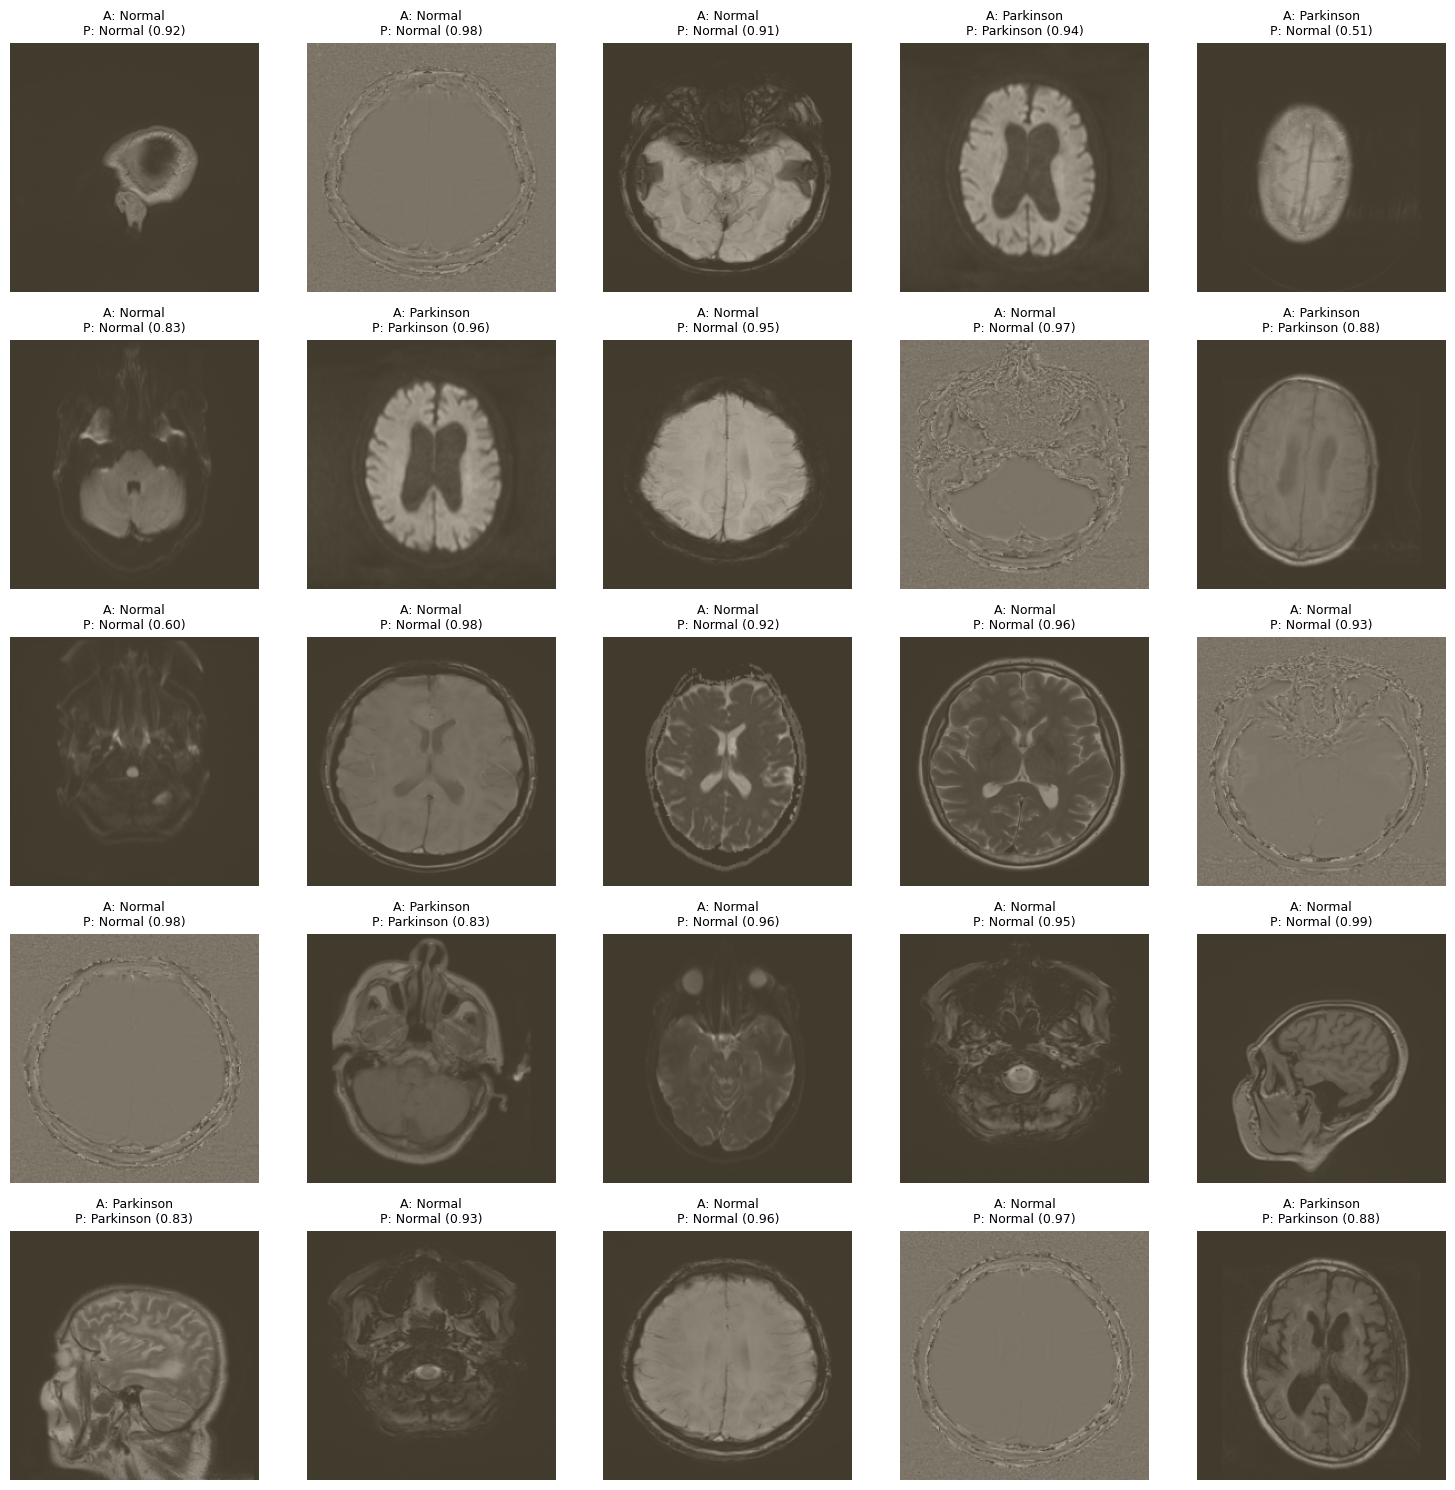

In [39]:
show_predictions(voting_model, model, pca, val_loader, device, num_images=25)